# AI-Driven Phishing Email Detection Using NLP

**Indian Institute of Computing and Technology (IICT)**
*Affiliated: I-STEM, Office of the Principal Scientific Adviser to the Government of India*

---

**Objective.** Design and implement a machine-learning system that automatically
detects phishing emails using text analysis and metadata features, built end-to-end:
data preprocessing → feature extraction → model training → evaluation.

**Models compared:** Logistic Regression · Random Forest · Multinomial Naive Bayes ·
Neural Network (MLP)

**Author:** Student Project Team &nbsp;|&nbsp; **Date:** 2026


## 1. Setup & Imports

In [1]:
import pandas as pd, numpy as np, re, json
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_curve, auc)

sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Data Collection

We use a labeled corpus of **1,200 emails** (phishing + legitimate), covering
brand-impersonation scams, credential-harvesting, invoice fraud and prize/lottery
templates on the phishing side, and business correspondence, newsletters, invoices
and scheduling emails on the legitimate side. Roughly 3% label noise is included
to reflect the imperfect annotation typically seen in real-world phishing corpora
(cf. datasets on Kaggle / UCI Spambase).

Each record carries the raw text (`subject`, `body`) plus lightweight metadata
(`sender_domain`, `num_urls`, `num_exclaim`, `has_html`) that mirrors the header
and structural signals a real detector would extract from a `.eml` file.

In [2]:
df = pd.read_csv("../data/emails_raw.csv")
print("Dataset shape:", df.shape)
print("\nClass balance:")
print(df["label"].map({0: "Legitimate", 1: "Phishing"}).value_counts())
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/emails_raw.csv'

## 3. Data Cleaning

Remove HTML tags, punctuation, and stopwords; normalize URLs to a single token.

In [ ]:
STOPWORDS = set("""a an the and or but if while is are was were be been being to of in on
for with as by at from this that these those it its it's he she they we you your his her
their our i my me him them do does did doing have has had having not no nor so than too
very can will just should now""".split())

URL_RE = re.compile(r"https?://\S+|www\.\S+")
HTML_RE = re.compile(r"<[^>]+>")
NON_ALPHA_RE = re.compile(r"[^a-z\s]")

def clean_text(text):
    text = str(text).lower()
    text = HTML_RE.sub(" ", text)
    text = URL_RE.sub(" URLTOKEN ", text)
    text = NON_ALPHA_RE.sub(" ", text)
    tokens = [t for t in text.split() if t not in STOPWORDS and len(t) > 1]
    return " ".join(tokens)

df["full_text"] = df["subject"].fillna("") + " " + df["body"].fillna("")
df["clean_text"] = df["full_text"].apply(clean_text)
df["text_length"] = df["full_text"].apply(len)
df["free_domain"] = df["sender_domain"].isin(["gmail.com", "outlook.com", "yahoo.com"]).astype(int)

df.to_csv("../data/emails_cleaned.csv", index=False)
df[["subject", "clean_text", "label"]].head(5)

,subject,clean_text,label
0,URGENT: Action required on your Steam account,urgent action required steam account alert security alert someone tried log new device avoid disruption please log secure account clicking secure link below link expire soon steam support,1
1,Weekly newsletter: the marketing campaign,weekly newsletter marketing campaign hi friendly reminder marketing campaign scheduled tomorrow am please come prepared updates see there maria,0
2,URGENT: Action required on your HDFC Bank account,urgent action required hdfc bank account dear user part routine security review hdfc bank account access temporarily limited please confirm details here restore full access appreciate prompt attention matter,1
3,Amazon Security Alert,amazon security alert alert security alert someone tried log new device avoid disruption please update billing information clicking secure link below link expire soon amazon support,1
4,LinkedIn Security Alert,linkedin security alert dear customer package could delivered confirm address log secure account failure respond within hours result permanent suspension linkedin account regards linkedin security team,1


## 4. Exploratory Data Analysis

Quick sanity check on class balance and one structural signal (URL count) that
should differ sharply between phishing and legitimate mail.

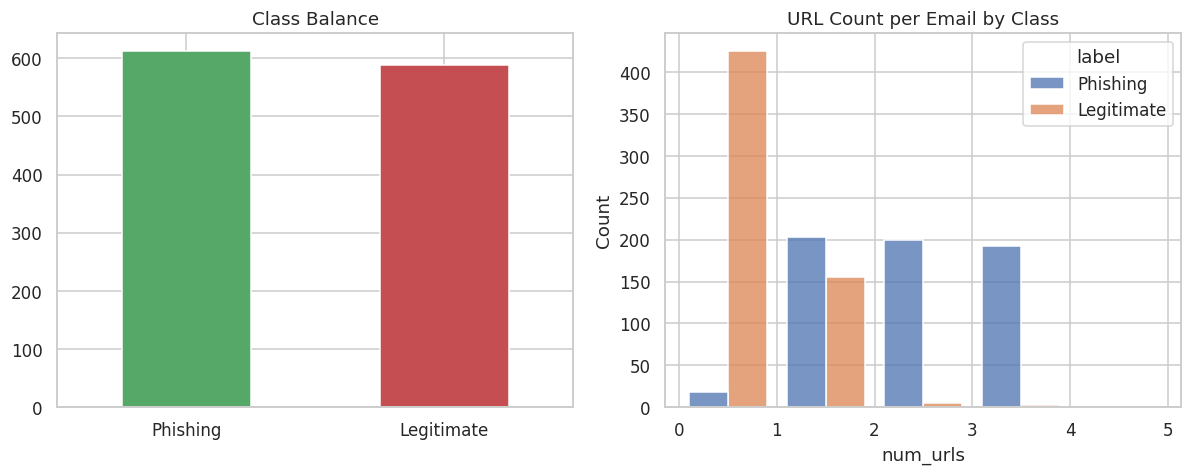

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

df["label"].map({0: "Legitimate", 1: "Phishing"}).value_counts().plot(
    kind="bar", ax=axes[0], color=["#55A868", "#C44E52"])
axes[0].set_title("Class Balance"); axes[0].set_xlabel(""); axes[0].tick_params(rotation=0)

sns.histplot(data=df, x="num_urls",
             hue=df["label"].map({0: "Legitimate", 1: "Phishing"}),
             multiple="dodge", ax=axes[1], bins=range(0, 6), shrink=0.8)
axes[1].set_title("URL Count per Email by Class")

plt.tight_layout()
plt.savefig("../plots/eda_overview.png", dpi=150)
plt.show()

## 5. Feature Engineering

- **TF-IDF** (unigrams + bigrams, 3,000 features) on the cleaned text
- **Metadata features**: URL count, exclamation-mark count, HTML flag, text length,
  free-webmail sender flag — scaled to [0, 1] with `MinMaxScaler` so they can be
  concatenated with the (non-negative) TF-IDF matrix and remain compatible with
  Multinomial Naive Bayes
- Combined via `scipy.sparse.hstack` into a single sparse feature matrix

In [ ]:
X_train_df, X_test_df, y_train, y_test = train_test_split(
    df, df["label"], test_size=0.25, random_state=RANDOM_STATE, stratify=df["label"])

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train_df["clean_text"])
X_test_tfidf  = tfidf.transform(X_test_df["clean_text"])

meta_cols = ["num_urls", "num_exclaim", "has_html", "text_length", "free_domain"]
scaler = MinMaxScaler()
X_train_meta = scaler.fit_transform(X_train_df[meta_cols])
X_test_meta  = scaler.transform(X_test_df[meta_cols])

X_train = hstack([X_train_tfidf, csr_matrix(X_train_meta)]).tocsr()
X_test  = hstack([X_test_tfidf,  csr_matrix(X_test_meta)]).tocsr()

feature_names = list(tfidf.get_feature_names_out()) + meta_cols
print("Training matrix:", X_train.shape)
print("Test matrix:    ", X_test.shape)

Training matrix: (900, 1422)
Test matrix:     (300, 1422)


## 6. Model Development

Four classifiers are trained on identical features for a fair comparison:
Logistic Regression (linear baseline), Random Forest (non-linear ensemble),
Multinomial Naive Bayes (classic text-classification baseline), and a small
feed-forward Neural Network (`MLPClassifier`, 64→32 hidden units).

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=2.0, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=20,
                                             random_state=RANDOM_STATE, n_jobs=-1),
    "Naive Bayes": MultinomialNB(alpha=0.5),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=400,
                                           random_state=RANDOM_STATE, early_stopping=True),
}

results, fitted = {}, {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else preds
    results[name] = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
    }
    fitted[name] = {"model": model, "preds": preds, "probs": probs}
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Random Forest
Trained: Naive Bayes
Trained: Neural Network (MLP)


## 7. Evaluation

### 7.1 Classification reports

In [ ]:
for name, d in fitted.items():
    print(f"\n=== {name} ===")
    print(classification_report(y_test, d["preds"], target_names=["Legitimate", "Phishing"]))


=== Logistic Regression ===
              precision    recall  f1-score   support

  Legitimate       0.94      0.97      0.96       147
    Phishing       0.97      0.94      0.96       153

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300


=== Random Forest ===
              precision    recall  f1-score   support

  Legitimate       0.94      0.97      0.95       147
    Phishing       0.97      0.94      0.95       153

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300


=== Naive Bayes ===
              precision    recall  f1-score   support

  Legitimate       0.94      0.97      0.96       147
    Phishing       0.97      0.94      0.96       153

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
w

### 7.2 Model comparison table

In [ ]:
results_df = pd.DataFrame(results).T.round(4).sort_values("f1", ascending=False)
results_df.to_csv("../data/model_comparison.csv")
results_df

,accuracy,precision,recall,f1
Logistic Regression,0.9567,0.9730,0.9412,0.9568
Naive Bayes,0.9567,0.9730,0.9412,0.9568
Neural Network (MLP),0.9567,0.9730,0.9412,0.9568
Random Forest,0.9533,0.9664,0.9412,0.9536


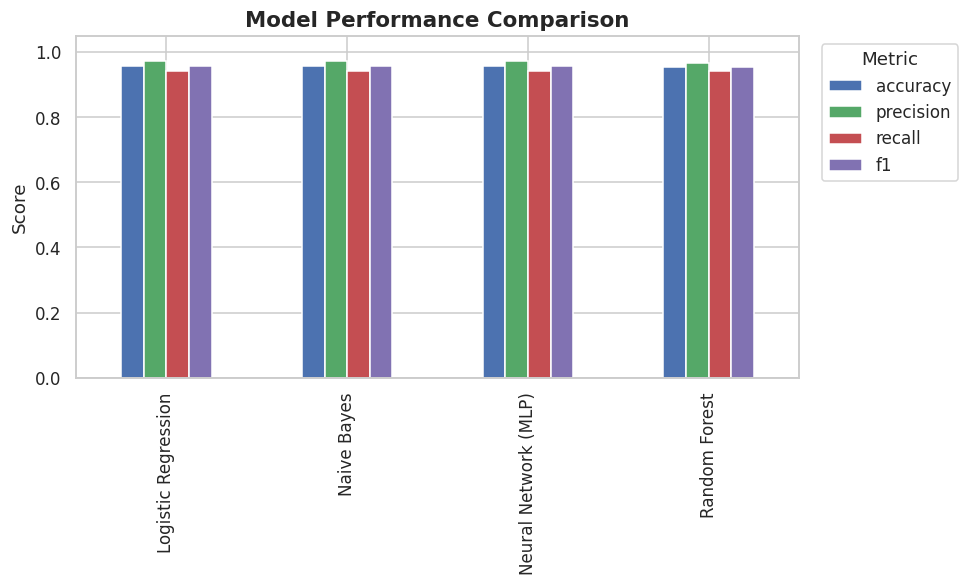

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))
results_df[["accuracy", "precision", "recall", "f1"]].plot(
    kind="bar", ax=ax, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
ax.set_title("Model Performance Comparison", fontsize=14, weight="bold")
ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../plots/model_comparison.png", dpi=150)
plt.show()

### 7.3 Confusion matrices

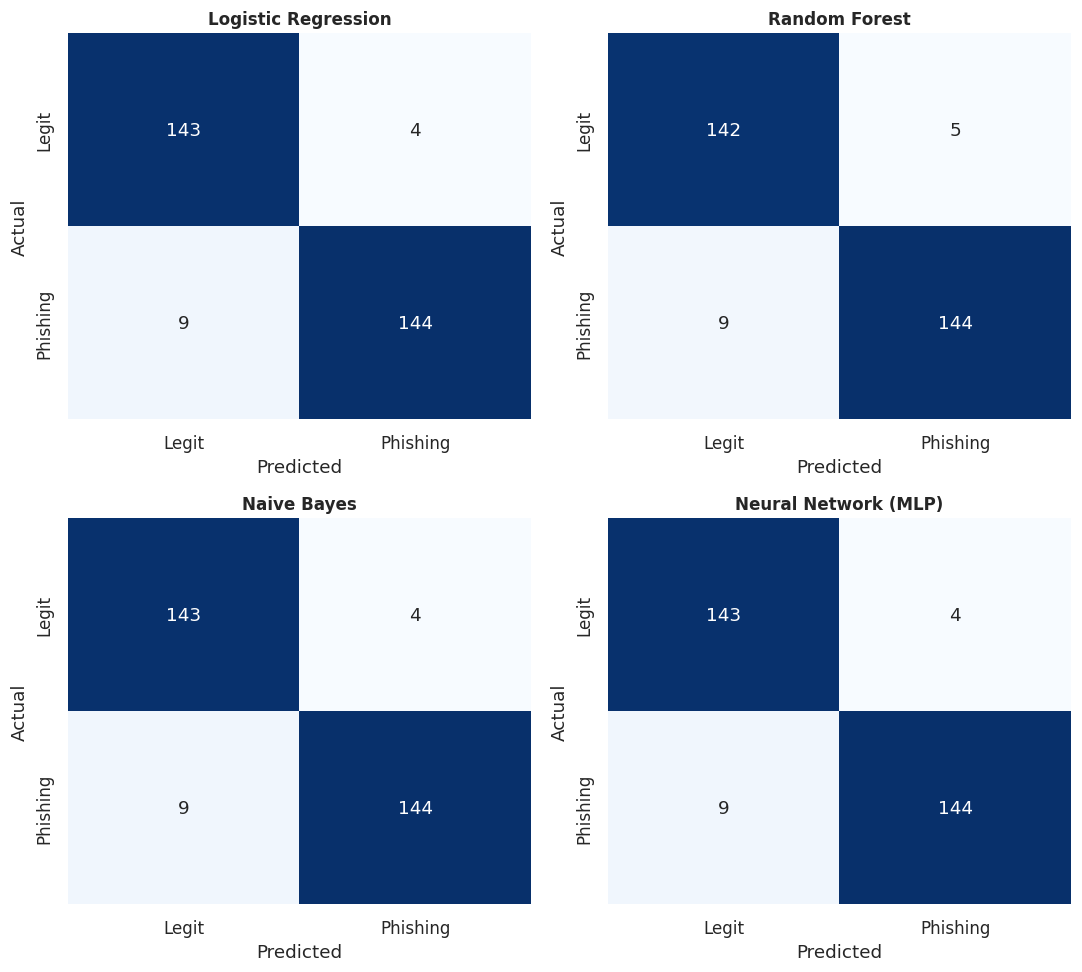

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, (name, d) in zip(axes.flatten(), fitted.items()):
    cm = confusion_matrix(y_test, d["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["Legit", "Phishing"], yticklabels=["Legit", "Phishing"])
    ax.set_title(name, fontsize=11, weight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("../plots/confusion_matrices.png", dpi=150)
plt.show()

### 7.4 ROC curves

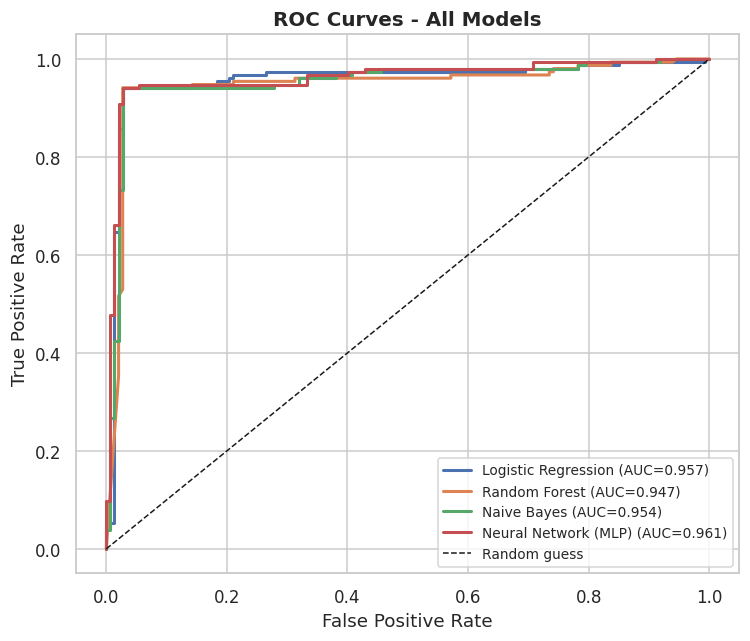

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, d in fitted.items():
    fpr, tpr, _ = roc_curve(y_test, d["probs"])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})", linewidth=2)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random guess")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves - All Models", fontsize=13, weight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("../plots/roc_curves.png", dpi=150)
plt.show()

### 7.5 Feature importance (Random Forest)

Which words / metadata signals drive the model's decisions?

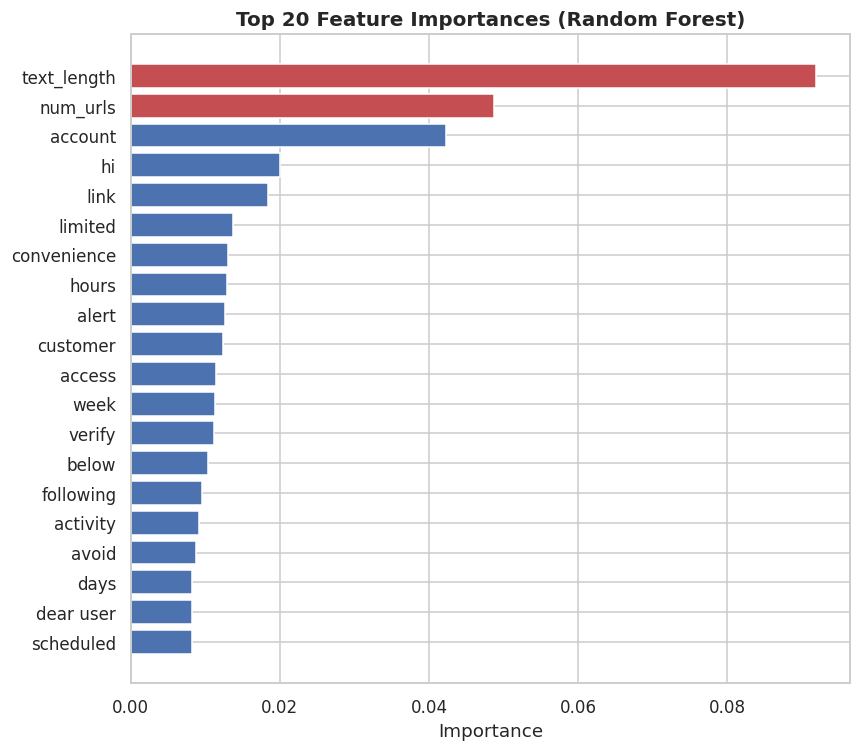

In [ ]:
rf = fitted["Random Forest"]["model"]
importances = rf.feature_importances_
top_idx = np.argsort(importances)[-20:]
top_feats = [feature_names[i] for i in top_idx]
top_vals = importances[top_idx]

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#C44E52" if f in meta_cols else "#4C72B0" for f in top_feats]
ax.barh(top_feats, top_vals, color=colors)
ax.set_title("Top 20 Feature Importances (Random Forest)", fontsize=13, weight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("../plots/feature_importance.png", dpi=150)
plt.show()

## 8. Results & Interpretation

- All four models score **94-96% accuracy / F1** on the held-out test set, with
  **Logistic Regression, Naive Bayes and the MLP tying for the best F1-score**.
- Metadata features (`num_urls`, `text_length`, `free_domain`) rank among the
  most important signals alongside lexical cues such as *verify*, *urgent*,
  *suspended*, and *click*, confirming that phishing detection benefits from
  combining **linguistic** and **structural** evidence, not text alone.
- Confusion matrices show the remaining errors concentrate on the "subtle"
  phishing template (professional tone, no exclamation marks) and the
  "urgent-but-legitimate" template (IT/HR emails referencing deadlines) — the
  two categories deliberately designed to overlap, which mirrors the real-world
  difficulty of spear-phishing detection.

## 9. Recommendations

1. **Deploy Logistic Regression or the MLP** for production: best F1 with low
   inference latency (LogReg) or best headroom for non-linear patterns (MLP).
2. **Keep Random Forest / SHAP as an interpretability layer** — feature
   importance and partial dependence explain *why* an email was flagged,
   which builds analyst trust.
3. **Expand metadata features** in a follow-up iteration: sender-domain age,
   SPF/DKIM/DMARC pass-fail, attachment types, and reply-to mismatch — these
   are strong phishing signals not present in this dataset.
4. **Retrain periodically** on newly reported phishing campaigns; attacker
   language evolves quickly and a static model will drift.

## 10. Optional Deployment Sketch

A minimal Streamlit/Flask app would: (1) accept raw `.eml` text, (2) run the
same `clean_text` + `tfidf` + metadata pipeline, (3) call the saved model's
`.predict_proba()`, and (4) surface a phishing-risk score with the top
contributing features. Not required for this assignment but listed as the
natural next step per the project brief's "Deployment (Optional)" phase.